# 20240912

Differences - Statistics=0.8609605673546249, p-value=1.0287043159831349e-05
Differences: Sample does not look Gaussian (reject H0)
Differences - Statistics=0.9651211407392012, p-value=0.34064091013769443
Differences: Sample looks Gaussian (fail to reject H0)
Differences - Statistics=0.9639173329072657, p-value=0.13728422734150114
Differences: Sample looks Gaussian (fail to reject H0)
Differences - Statistics=0.9256629901933213, p-value=0.00739730345619592
Differences: Sample does not look Gaussian (reject H0)
Differences - Statistics=0.9375041728021576, p-value=0.07792842390971703
Differences: Sample looks Gaussian (fail to reject H0)
Differences - Statistics=0.9006365844627411, p-value=0.03061078698975556
Differences: Sample does not look Gaussian (reject H0)


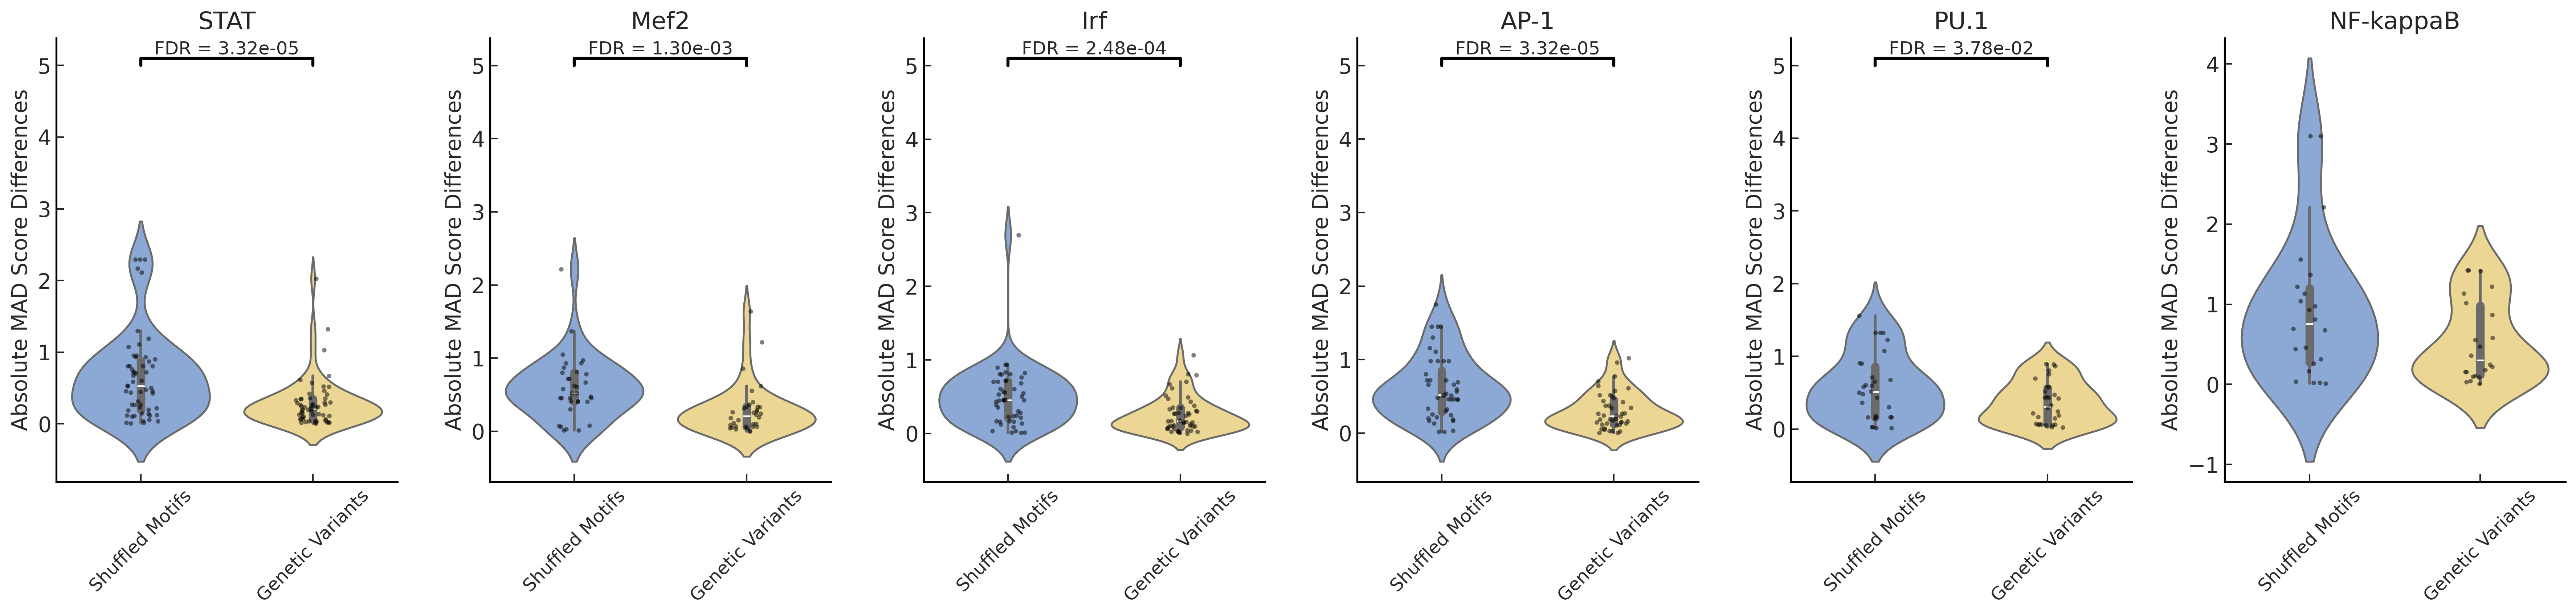

(array([3.31936882e-05, 1.30235801e-03, 2.47776030e-04, 3.31936882e-05,
        3.77955914e-02, 3.70531082e-01]),)

In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import multipletests
import warnings

# Suppress future warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

# Update global Matplotlib font settings
plt.rcParams.update({
    'axes.titlesize': 21,
    'axes.labelsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'font.size': 14
})

def process_data(index_file, ref_file, alt_file, filtered_df, motif, statistics):
    # Reading the data
    df_index2 = pd.read_csv(index_file, index_col=0)
    df_ref = pd.read_csv(ref_file, index_col=0)
    df_alt = pd.read_csv(alt_file, index_col=0)

    # Merging with index data
    df_ref = pd.merge(df_ref, df_index2, left_index=True, right_index=True, how='left')
    df_alt = pd.merge(df_alt, df_index2, left_index=True, right_index=True, how='left')

    # Filtering and processing data
    df_alt_index_motif = df_alt[df_alt[motif] == 1]
    df_alt_index_altonly = df_alt_index_motif[df_alt_index_motif.index.isin(filtered_df['alt'])]
    df_alt_final = pd.merge(filtered_df.set_index("alt"), df_alt_index_altonly, right_index=True, left_index=True)
    df_ref_final = df_ref.loc[df_alt_final.index]
    df_motif_final = df_alt.loc[df_alt_final["motif"]]
    df_alt_difference = df_alt_final[statistics] - df_ref_final[statistics]
    df_motif_difference = np.array(df_motif_final[statistics]) - np.array(df_ref_final[statistics])

    # Preparing final DataFrame
    combined_difference_abs = pd.DataFrame({
        'Shuffled Motifs': abs(df_motif_difference),
        'Genetic Variants': abs(np.array(df_alt_difference))
    }, index=df_alt_difference.index)
    combined_difference_reset = combined_difference_abs.reset_index()
    combined_long = combined_difference_reset.melt(id_vars=combined_difference_reset.columns[0],
                                                    value_vars=['Shuffled Motifs', 'Genetic Variants'])
    combined_long.columns = ['alt', 'Condition', 'MAD Score']

    return combined_long

def plot_violinplot(combined_data, subset1, title, subset2, p_values, offset=2, ax=None):
    # Increase Seaborn font scale
    sns.set(style="whitegrid", font_scale=1.5)
    plt.rcParams['figure.dpi'] = 300

    if ax is None:
        ax = plt.gca()  # Get the current active axes

    sns.violinplot(x='Condition', y='MAD Score', data=combined_data,
                   palette=["#80A6E2", "#FBDD85"], alpha=1, ax=ax)
    sns.stripplot(x='Condition', y='MAD Score', data=combined_data, jitter=True,
                  color='black', alpha=0.5, size=3, ax=ax)  # increased point size

    # Calculate the differences between subset1 and subset2
    differences = np.array(subset1) - np.array(subset2)

    # Perform Shapiro-Wilk test on the differences
    stat, p = stats.shapiro(differences)
    print(f'Differences - Statistics={stat}, p-value={p}')

    # Interpret the results
    alpha = 0.05  # significance level
    if p > alpha:
        print('Differences: Sample looks Gaussian (fail to reject H0)')
        t_statistic, p_value = stats.ttest_rel(subset1, subset2)
    else:
        print('Differences: Sample does not look Gaussian (reject H0)')
        statistic, p_value = stats.wilcoxon(subset1, subset2)

    # Append the p-value to the list for FDR correction
    p_values.append(p_value)

    # Refine grid and axis
    ax.xaxis.grid(False)
    ax.yaxis.grid(False)
    ax.spines['bottom'].set_color('black')
    ax.spines['left'].set_color('black')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    
    # Rotate and set tick labels with larger font sizes
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, fontsize=12)
    ax.tick_params(axis='x', direction='in', length=5, width=1)
    ax.tick_params(axis='y', direction='in', length=5, width=1)

    # Set axis labels and title with larger font sizes
    ax.set_ylabel('Absolute MAD Score Differences', fontsize=14)
    ax.set_xlabel('', fontsize=14)
    ax.set_title(title, fontsize=16)

def create_combined_plot_paired_t_test(ref, alt, save_file):
    # Transcription factors to plot
    tfs = ["STAT", "Mef2", "Irf", "AP-1", "PU.1", "NF-kappaB"]
    
    # Load filtered_df from a file or create it before calling the function
    filtered_df = pd.read_csv("indexing/ALT_REF_LookUpTable_filtered_amended_motif_alt_ref_20240127.csv")
    
    # Create a large figure to hold all subplots
    fig, axes = plt.subplots(1, len(tfs), figsize=(len(tfs) * 4, 6))  # Adjust the size as needed
    
    # List to store all p-values
    p_values = []
    
    for i, tf in enumerate(tfs):
        # Process data for each transcription factor
        combined_long = process_data('indexing/index_20240125_curated.csv',
                                     ref, alt,
                                     filtered_df, tf, 'mad.score')
        
        # Extract subsets for plotting
        subset1 = abs(combined_long[combined_long['Condition'] == 'Shuffled Motifs']['MAD Score'])
        subset2 = abs(combined_long[combined_long['Condition'] == 'Genetic Variants']['MAD Score'])
        
        # Plot the violin plot on the ith subplot and collect p-values
        plot_violinplot(combined_long, subset1, tf, subset2, p_values, offset=2, ax=axes[i])
    
    # Apply FDR correction after collecting all p-values
    rejected, corrected_p_values, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')

    # Add corrected p-values to plots
    for i, ax in enumerate(axes):
        if corrected_p_values[i] <= 0.05:  # Significant after FDR correction
            y_coord = max(combined_long['MAD Score']) + 2  # Adjust offset as needed
            ax.plot([0, 0, 1, 1], [y_coord - 0.1, y_coord, y_coord, y_coord - 0.1], lw=2, c='black')
            ax.text(0.5, y_coord, f'FDR = {corrected_p_values[i]:.2e}', ha='center', va='bottom', fontsize=12)
    
    plt.tight_layout()
    plt.savefig(save_file, format='pdf', dpi=300)
    plt.show()
    return corrected_p_values,
# Call the function to create the combined plot
create_combined_plot_paired_t_test(
    ref='enhancer_activities/THP1Macrophage_byAllele/20240912_MPRA3_MAD_mergedREF.csv',
    alt='enhancer_activities/THP1Macrophage_byAllele/20240912_MPRA3_MAD_mergedALT.csv',
    save_file="violinplot_motifdisrupt_madscore_tmp.pdf"
)


In [9]:
df_index=pd.read_csv('indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_202401021.csv',index_col=0)
df_index = df_index[['Mef2',	'PU.1',	'Irf'	,'STAT',	'NF-kappaB',	'AP-1']]

In [10]:
df_alref=pd.read_csv("indexing/ALT_REF_LookUpTable_filtered_amended_motif_alt_ref_20240127.csv",index_col=0)

In [11]:
df_alref_sorted = df_alref.loc[tissue_df.index]


In [12]:
df_alref_sorted_motif = pd.merge(df_alref_sorted,df_index.loc[df_alref.loc[tissue_df.index]['alt']],left_on="alt",right_index=True)

In [13]:
df_final = pd.merge(tissue_df,df_alref_sorted_motif,left_index=True,right_index=True).reset_index().drop_duplicates(subset="index").set_index('index')
df_final

,20240812_comparative_HMC3_motif,20240611_comparative_THP1Macrophage_motif,20240616_comparative_BrainR1R2merged20240404_motif,20240719_comparative_HEK293T_motif,ref,alt,Mef2,PU.1,Irf,STAT,NF-kappaB,AP-1
index,,,,,,,,,,,,
rs10130373:chr14:92466231:C:A:92465994:92466494:92466244_motifdisrupt,-0.155768,-0.171544,NaN,-0.148729,ref:rs4904922:PEAKCENTER:chr14:92466135:G:C:92...,alt:rs10130373:PEAKCENTER:chr14:92466231:C:A:9...,0,1,0,0,0,0
rs72838288:chr2:127135449:C:A:127135119:127135619:127135369_motifdisrupt,NaN,-0.040866,NaN,NaN,ref:rs72838287:PEAKCENTER:chr2:127135380:C:G:1...,alt:rs72838288:PEAKCENTER:chr2:127135449:C:A:1...,0,0,0,0,0,1
rs9304646:chr19:44947151:T:A:44946977:44947477:44947227_motifdisrupt,-0.604965,-0.502034,NaN,-0.404344,ref:rs9304646:PEAKCENTER:chr19:44947151:T:A:44...,alt:rs9304646:PEAKCENTER:chr19:44947151:T:A:44...,0,0,0,1,0,0
rs113046258:chr19:58183782:A:G:58182601:58184100:58183816_motifdisrupt,-0.136801,0.067527,NaN,-0.220483,ref:rs113046258:PEAKCENTER:chr19:58183782:A:G:...,alt:rs113046258:PEAKCENTER:chr19:58183782:A:G:...,1,0,1,1,0,1
rs113046258:chr19:58183782:A:G:58182737:58183975:58183741_motifdisrupt,NaN,0.164776,0.209627,NaN,ref:rs113046258:PEAKCENTER:chr19:58183782:A:G:...,alt:rs113046258:PEAKCENTER:chr19:58183782:A:G:...,1,0,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
rs9271068:chr6:32575674:C:G:32575391:32575891:32575641_motifdisrupt,0.150302,0.100460,NaN,0.202475,ref:rs9271063:PEAKCENTER:chr6:32575584:A:G:325...,alt:rs9271068:PEAKCENTER:chr6:32575674:C:G:325...,0,0,0,0,1,0
rs9271090:chr6:32576247:T:C:32576044:32576544:32576294_motifdisrupt,-0.129696,NaN,NaN,-0.214313,ref:rs9271090:PEAKCENTER:chr6:32576247:T:C:325...,alt:rs9271090:PEAKCENTER:chr6:32576247:T:C:325...,0,0,0,0,1,0
rs9271170:chr6:32577889:T:C:32577256:32578131:32577812_motifdisrupt,NaN,-0.101499,0.413414,-0.243702,ref:rs9271163:PEAKCENTER:chr6:32577733:C:T:325...,alt:rs9271170:PEAKCENTER:chr6:32577889:T:C:325...,0,0,0,1,0,0


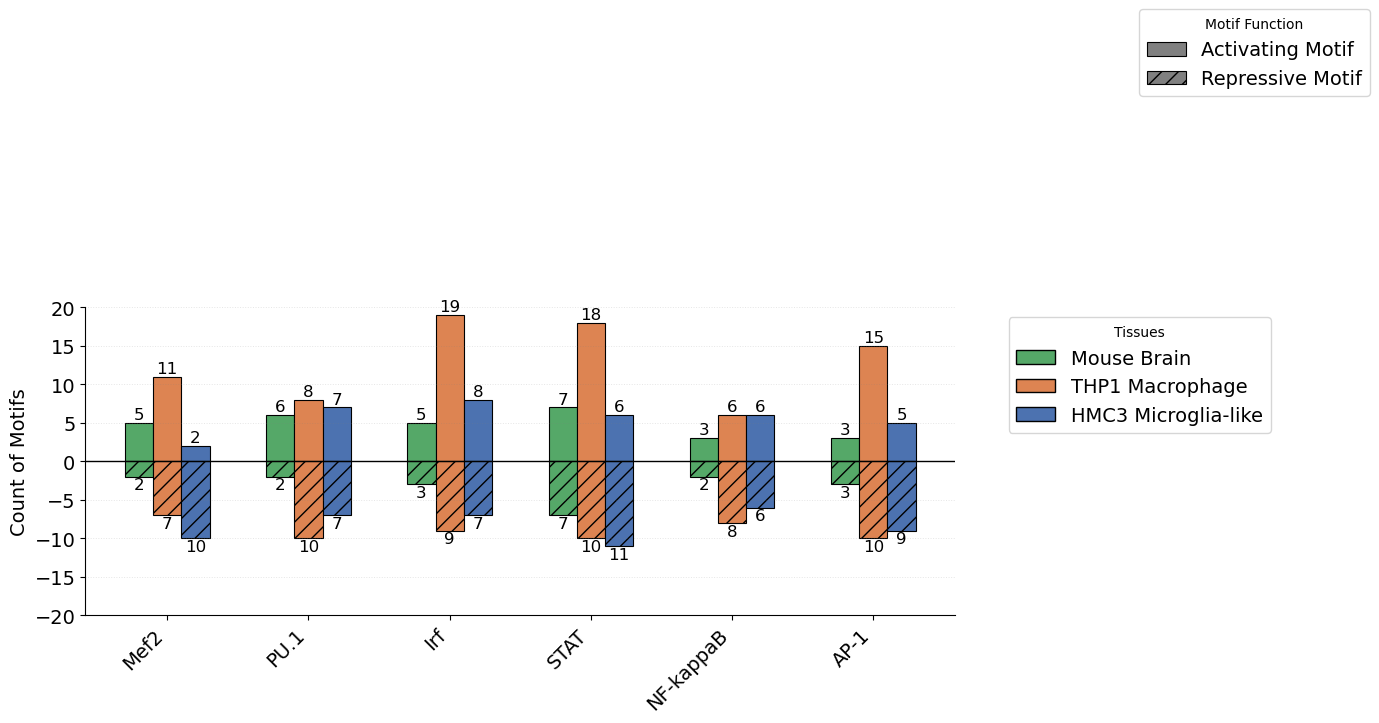

In [18]:
import matplotlib.pyplot as plt

# Reordered tissues: Brain, THP1, HMC3
tissues = [
    '20240616_comparative_BrainR1R2merged20240404_motif',    # Will be "Mouse Brain"
    '20240611_comparative_THP1Macrophage_motif',             # Will be "THP1 Macrophage"
    '20240812_comparative_HMC3_motif'                        # Will be "HMC3 Microglia-like"
]

tfs = ['Mef2', 'PU.1', 'Irf', 'STAT', 'NF-kappaB', 'AP-1']

# Nature-compatible color palette
tissue_colors = {
    '20240616_comparative_BrainR1R2merged20240404_motif': '#55A868',  # Green (Brain)
    '20240611_comparative_THP1Macrophage_motif': '#DD8452',           # Orange (THP1)
    '20240812_comparative_HMC3_motif': '#4C72B0'                      # Blue (HMC3)
}

# Updated legend labels
legend_labels = {
    '20240616_comparative_BrainR1R2merged20240404_motif': 'Mouse Brain',
    '20240611_comparative_THP1Macrophage_motif': 'THP1 Macrophage',
    '20240812_comparative_HMC3_motif': 'HMC3 Microglia-like'
}

results = {tf: {'>0': [], '<0': [], 'total': []} for tf in tfs}

for tf in tfs:
    filtered_df = df_final[df_final[tf] == 1]
    for tissue in tissues:
        tissue_values = filtered_df[tissue].dropna()
        positive_count = (tissue_values > 0).sum()
        negative_count = (tissue_values < 0).sum()
        total_count = positive_count + negative_count if (positive_count + negative_count) > 0 else 1
        results[tf]['>0'].append(positive_count)
        results[tf]['<0'].append(negative_count)
        results[tf]['total'].append(total_count)

fig, ax = plt.subplots(figsize=(12, 4))

bar_width = 0.2
x = range(len(tfs))

# Draw a baseline at y=0
ax.axhline(0, color='black', linewidth=1)

# Add light, dotted, transparent gridlines
ax.yaxis.grid(True, linestyle=':', linewidth=0.7, color='gray', alpha=0.2)

# Offsets for the labels so they don't overlap with the bar edges
pos_label_offset = 0.1
neg_label_offset = -0.1

for i, tf in enumerate(tfs):
    for j, tissue in enumerate(tissues):
        positive_count = results[tf]['>0'][j]
        negative_count = results[tf]['<0'][j]
        x_position = i + j * bar_width
        
        # Positive bars above zero
        if positive_count > 0:
            ax.bar(
                x_position, 
                positive_count, 
                width=bar_width,
                color=tissue_colors[tissue],
                edgecolor='black',
                linewidth=0.8
            )
            # Add label at the top of the positive bar
            ax.text(
                x_position,
                positive_count + pos_label_offset,
                str(positive_count),
                ha='center',
                va='bottom',
                fontsize=12
            )
        
        # Negative bars below zero
        if negative_count > 0:
            ax.bar(
                x_position,
                -negative_count, 
                width=bar_width,
                color=tissue_colors[tissue],
                edgecolor='black',
                linewidth=0.8,
                hatch='//'
            )
            # Add label at the bottom of the negative bar
            ax.text(
                x_position,
                -(negative_count) + neg_label_offset,
                str(negative_count),
                ha='center',
                va='top',
                fontsize=12
            )

# Customize plot
ax.set_ylabel('Count of Motifs', fontsize=14)
ax.set_xticks([pos + (bar_width * (len(tissues)-1) / 2) for pos in x])
ax.set_xticklabels(tfs, rotation=45, ha='right', fontsize=14)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend for tissues
tissue_patches = [plt.Rectangle((0,0),1,1, facecolor=tissue_colors[t], edgecolor='black') for t in tissues]
tissue_legend_labels = [legend_labels[t] for t in tissues]
leg_tissues = ax.legend(tissue_patches, tissue_legend_labels, title='Tissues', loc='upper left', bbox_to_anchor=(1.05, 1.0),fontsize=14)

# Legend for sign (>0 or <0)
pos_patch = plt.Rectangle((0,0),1,1, facecolor='gray', edgecolor='black', linewidth=0.8)
neg_patch = plt.Rectangle((0,0),1,1, facecolor='gray', edgecolor='black', linewidth=0.8, hatch='//')
leg_sign = ax.legend([pos_patch, neg_patch], ['Activating Motif', 'Repressive Motif'], title='Motif Function', 
                     loc='upper left', bbox_to_anchor=(1.2, 2),fontsize=14)

# Add the tissue legend and sign legend
ax.add_artist(leg_tissues)
plt.ylim(-20,20)
plt.yticks(fontsize=14)
# Adjust layout to leave space on the right for legends
fig.subplots_adjust(right=0.85)  # Leave space on the right for the legends

# Save the figure as a high-resolution PDF
plt.savefig('stacked_barplot_motifdisrupt.pdf', dpi=300, bbox_inches='tight')
plt.show()
